# 04 — Model Evaluation

In [1]:
import pickle, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

with open('../models/train_test_data.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test, feature_names = pickle.load(f)

trained_models = joblib.load('../models/all_models.pkl')
print('Models loaded!')

Models loaded!


In [2]:
# Evaluate all models
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df.sort_values('AUC-ROC', ascending=False)

,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
Logistic Regression,0.8033,0.8000,0.8485,0.8235,0.8712
Random Forest,0.7541,0.7647,0.7879,0.7761,0.8588
SVM,0.7705,0.7714,0.8182,0.7941,0.8420
KNN,0.7869,0.7778,0.8485,0.8116,0.8377
XGBoost,0.7213,0.7353,0.7576,0.7463,0.8323


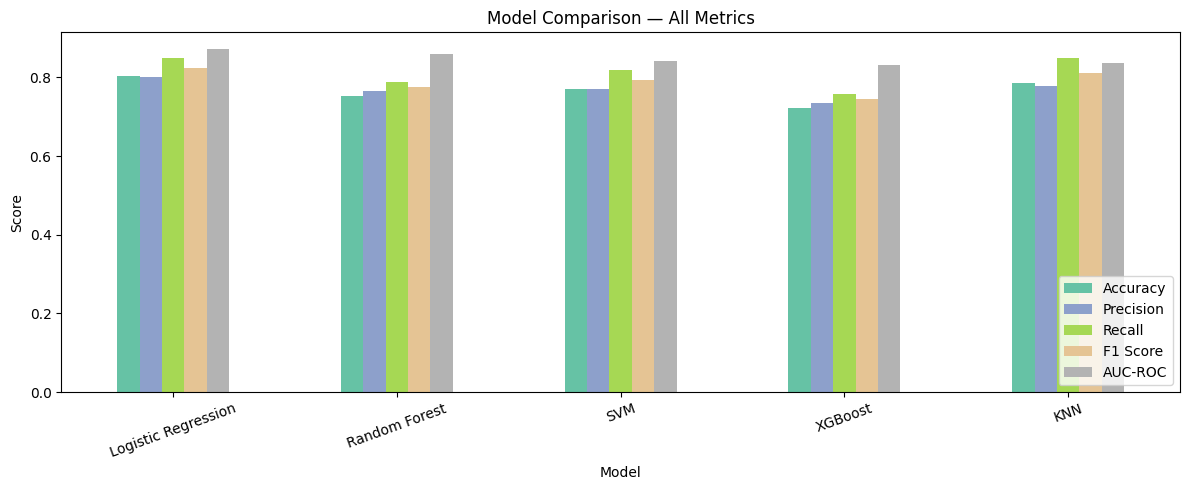

In [3]:
# Metrics bar chart
results_df.plot(kind='bar', figsize=(12,5), colormap='Set2')
plt.title('Model Comparison — All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../report/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

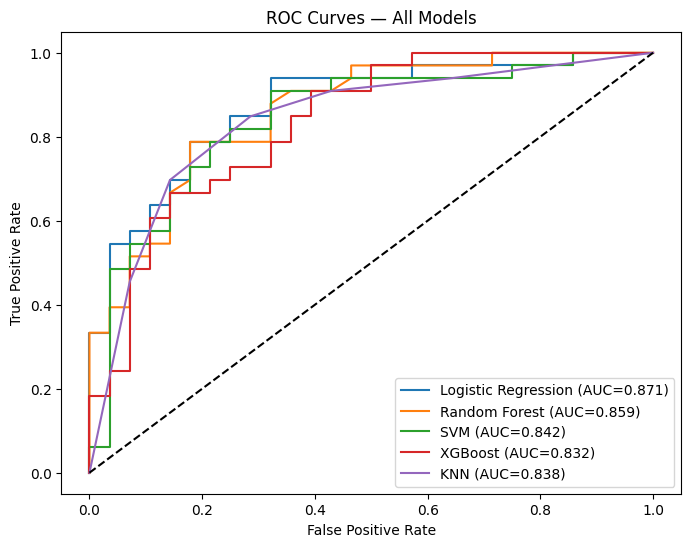

In [4]:
# ROC curves for all models
plt.figure(figsize=(8,6))
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.savefig('../report/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

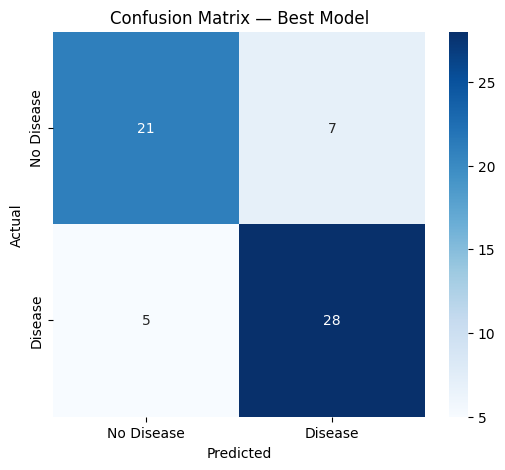

In [5]:
# Confusion matrix for best model
best_model = joblib.load('../models/best_model.pkl')
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
plt.title('Confusion Matrix — Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../report/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Classification report
print(classification_report(y_test, y_pred, target_names=['No Disease','Disease']))

              precision    recall  f1-score   support

  No Disease       0.81      0.75      0.78        28
     Disease       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61

